# What Drives Larger Tech Layoffs?
### Analysing the Role of Funding Stage, Industry, and Capital Raised

![Python](https://img.shields.io/badge/Python-3.10+-3776AB?style=flat&logo=python&logoColor=white)
![Jupyter](https://img.shields.io/badge/Jupyter-Notebook-F37626?style=flat&logo=jupyter&logoColor=white)
![Status](https://img.shields.io/badge/Status-Complete-2ea44f?style=flat)
![Dataset](https://img.shields.io/badge/Dataset-Kaggle-20BEFF?style=flat&logo=kaggle&logoColor=white)

---

> **Dataset:** [Tech Layoffs 2020-2025](https://www.kaggle.com/datasets/ulrikeherold/tech-layoffs-2020-2024) - 2,412 layoff events across tech companies worldwide, compiled from public reports.


---
## 1. Executive Summary

The 2022-2023 tech layoff wave erased over 400,000 jobs globally, affecting companies from early-stage startups to post-IPO giants. This project investigates what structural and financial characteristics are associated with larger layoffs, using a dataset of 2,412 reported layoff events spanning 2020 to 2025.

Two questions are explored:

1. Are well-funded companies less likely to cut large proportions of their workforce? *(Method 1: Spearman correlation + OLS regression)*
2. Does layoff severity differ significantly across funding stages? *(Method 2: Kruskal-Wallis test)*

**Key findings:**
- Companies that raised more capital tend to cut a smaller share of their workforce (Spearman rho = -0.316, p < 0.001), but the effect is modest (OLS R2 approx. 10%).
- Funding stage has a significant effect on layoff severity (Kruskal-Wallis H = 277.92, p < 0.001): early-stage companies face proportionally larger cuts than mature ones.
- Layoffs peaked in early 2023, concentrated in Consumer, Retail, and Finance sectors.


---
## 2. Introduction

### 2.1 Dataset Description

The dataset covers publicly reported layoff events across global technology companies from March 2020 through early 2025. Each row represents a single layoff event at a company, with the following key variables:

| Variable | Description |
|---|---|
| `Company` | Company name |
| `Laid_Off` | Absolute number of employees laid off |
| `Percentage` | Share of total workforce laid off (%) |
| `Date_layoffs` | Date of the layoff event |
| `Industry` | Sector (Finance, Retail, Healthcare, etc.) |
| `Stage` | Funding stage at time of layoff (Seed to Post-IPO) |
| `Money_Raised_in__mil` | Total capital raised by the company ($M) |
| `Company_Size_before_Layoffs` | Headcount before the event |
| `Country` / `Continent` | Geographic location of HQ |

The dataset contains 2,412 events. Missing values are present in `Laid_Off` (372), `Percentage` (449), `Money_Raised_in__mil` (364), and `Stage` (164). Each variable is analysed on its available complete cases, without imputation.

### 2.2 Research Question

**What structural and financial characteristics of tech companies are associated with larger proportional layoffs?**

### 2.3 Hypotheses

**H1 (Method 1):** Companies that raised more capital will cut a smaller proportion of their workforce.
- H0: rho = 0 (no monotonic association between funds raised and % laid off)
- H1: rho < 0 (more capital is associated with a smaller proportional cut)

**H2 (Method 2):** Layoff severity (as % of workforce) differs significantly across funding stages.
- H0: All stage groups have the same distribution of % laid off
- H1: At least one stage group differs significantly from the others

These hypotheses address a practical business question: does financial maturity act as a buffer against large workforce reductions?


---
## 3. Exploratory Data Analysis

### 3.1 Imports, Output Folder, and Data Loading

**Reproducibility note:** The `os.makedirs("images", exist_ok=True)` call in the cell below creates the `images/` folder the first time the notebook is run. Every plot is saved there via `plt.savefig(...)`, so running all cells from top to bottom regenerates all figures from the raw data with no manual steps required.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kruskal, mannwhitneyu
from scipy import stats as scipy_stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# ── Create images folder automatically on first run ───────────────────────────
# All plt.savefig() calls in this notebook write here, making the analysis
# fully reproducible: clone the repo, run all cells, and every figure is
# regenerated from the raw data with no manual steps required.
os.makedirs("images", exist_ok=True)

# ── Plot styling ──────────────────────────────────────────────────────────────
PALETTE = ["#2C6E9B", "#E07B39", "#3D9970", "#C44E52", "#8172B2", "#937860", "#DA8BC3"]
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130})

# ── Load dataset ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv('tech_layoffs_til_2025.csv')
df_raw['Date_layoffs'] = pd.to_datetime(df_raw['Date_layoffs'], errors='coerce')
df_raw['YearMonth']    = df_raw['Date_layoffs'].dt.to_period('M')

print(f"Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)


Dataset shape: 2,412 rows × 19 columns


,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude,YearMonth
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766,2020-03
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766,2020-03
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329,2020-03


### 3.2 Overview: Structure, Completeness, and Descriptive Statistics

In [2]:
# ── Dataset structure ─────────────────────────────────────────────────────────
print("── Data types and non-null counts ──")
df_raw.info()

# ── Missing values ─────────────────────────────────────────────────────────────
print("\n── Missing values per column ──")
missing = df_raw.isnull().sum()
display(missing[missing > 0].sort_values(ascending=False).to_frame("Missing Count"))

# ── Numeric summary ────────────────────────────────────────────────────────────
print("\n── Descriptive statistics (numeric variables) ──")
display(df_raw[['Laid_Off', 'Percentage', 'Company_Size_before_Layoffs',
                'Money_Raised_in__mil']].describe().T.round(2))


── Data types and non-null counts ──
<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Nr                           2412 non-null   int64         
 1   Company                      2412 non-null   str           
 2   Location_HQ                  2412 non-null   str           
 3   Region                       2412 non-null   str           
 4   USState                      2411 non-null   str           
 5   Country                      2412 non-null   str           
 6   Continent                    2412 non-null   str           
 7   Laid_Off                     2040 non-null   float64       
 8   Date_layoffs                 2412 non-null   datetime64[us]
 9   Percentage                   1963 non-null   float64       
 10  Company_Size_before_Layoffs  1769 non-null   float64       
 11  Company_Size_afte

,Missing Count
Company_Size_before_Layoffs,643
Company_Size_after_layoffs,555
Percentage,449
Laid_Off,372
Money_Raised_in__mil,364
Stage,164
USState,1



── Descriptive statistics (numeric variables) ──


,count,mean,std,min,25%,50%,75%,max
Laid_Off,2040.0,366.08,1406.97,1.0,40.0,95.0,200.00,30000.0
Percentage,1963.0,26.16,27.42,0.0,9.6,16.0,30.00,100.0
Company_Size_before_Layoffs,1769.0,4490.32,26452.74,0.0,215.0,571.0,1538.00,600000.0
Money_Raised_in__mil,2048.0,683.78,4292.58,0.0,50.0,161.0,451.25,121900.0


### 3.3 Temporal Distribution

How did layoff volumes evolve across the 2020-2025 period?

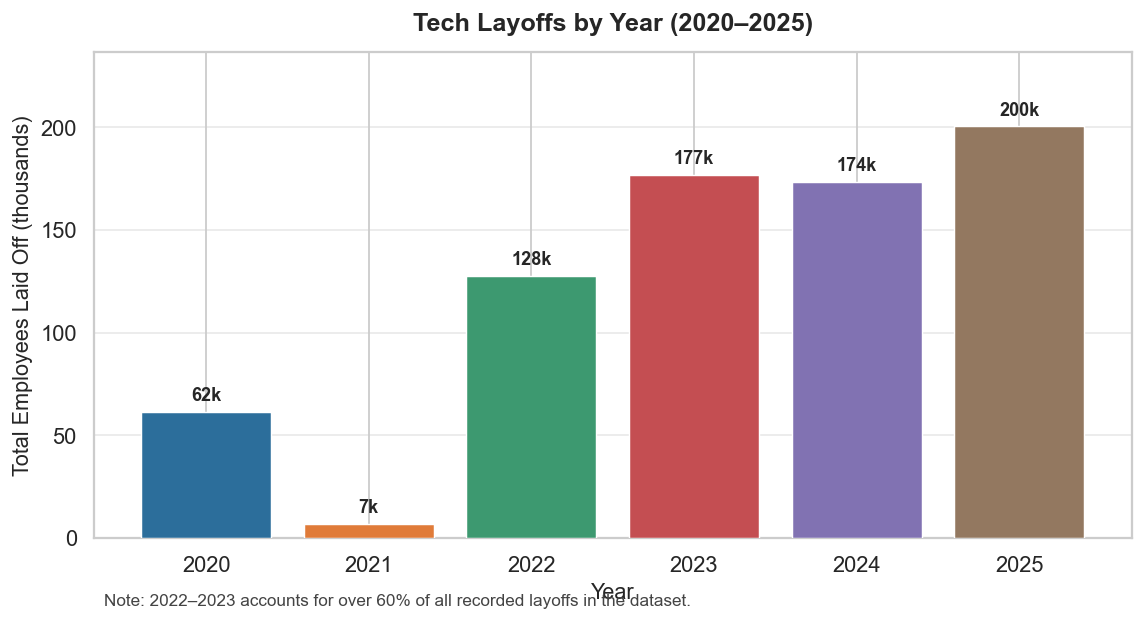

In [3]:
# ── Total layoffs per year ────────────────────────────────────────────────────
year_total = df_raw.groupby('Year')['Laid_Off'].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(year_total['Year'].astype(str), year_total['Laid_Off'] / 1000,
              color=PALETTE, edgecolor='white', linewidth=0.8, zorder=3)
ax.bar_label(bars, labels=[f"{v/1000:.0f}k" for v in year_total['Laid_Off']],
             padding=4, fontsize=10, fontweight='bold')
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Employees Laid Off (thousands)", fontsize=12)
ax.set_title("Tech Layoffs by Year (2020–2025)", fontsize=14, fontweight='bold', pad=12)
ax.set_ylim(0, year_total['Laid_Off'].max() / 1000 * 1.18)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.text(0.01, -0.14, "Note: 2022–2023 accounts for over 60% of all recorded layoffs in the dataset.",
        transform=ax.transAxes, fontsize=9.5, color='#444')
plt.tight_layout()
plt.savefig('images/layoffs_per_year.png', bbox_inches='tight', dpi=150)
plt.show()


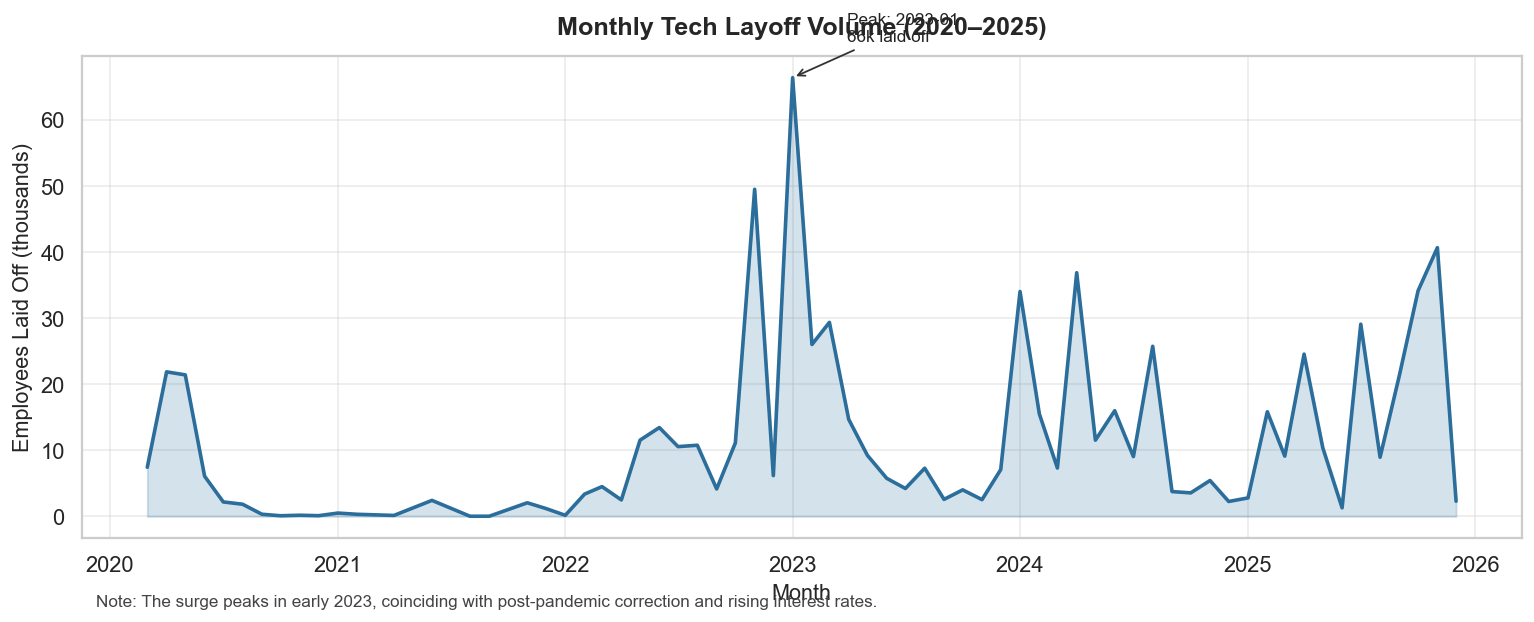

In [4]:
# ── Monthly timeline ──────────────────────────────────────────────────────────
monthly = df_raw.groupby('YearMonth')['Laid_Off'].sum().reset_index()
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(monthly['YearMonth_dt'], monthly['Laid_Off'] / 1000, alpha=0.2, color=PALETTE[0])
ax.plot(monthly['YearMonth_dt'], monthly['Laid_Off'] / 1000, color=PALETTE[0], lw=2)

peak = monthly.loc[monthly['Laid_Off'].idxmax()]
ax.annotate(f"Peak: {peak['YearMonth']}\n{int(peak['Laid_Off']/1000)}k laid off",
            xy=(peak['YearMonth_dt'], peak['Laid_Off'] / 1000),
            xytext=(30, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#333'), fontsize=9.5, color='#222')
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Employees Laid Off (thousands)", fontsize=12)
ax.set_title("Monthly Tech Layoff Volume (2020–2025)", fontsize=14, fontweight='bold', pad=12)
ax.grid(alpha=0.35)
ax.text(0.01, -0.14,
        "Note: The surge peaks in early 2023, coinciding with post-pandemic correction and rising interest rates.",
        transform=ax.transAxes, fontsize=9.5, color='#444')
plt.tight_layout()
plt.savefig('images/monthly_timeline.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.4 Industry and Sector Breakdown

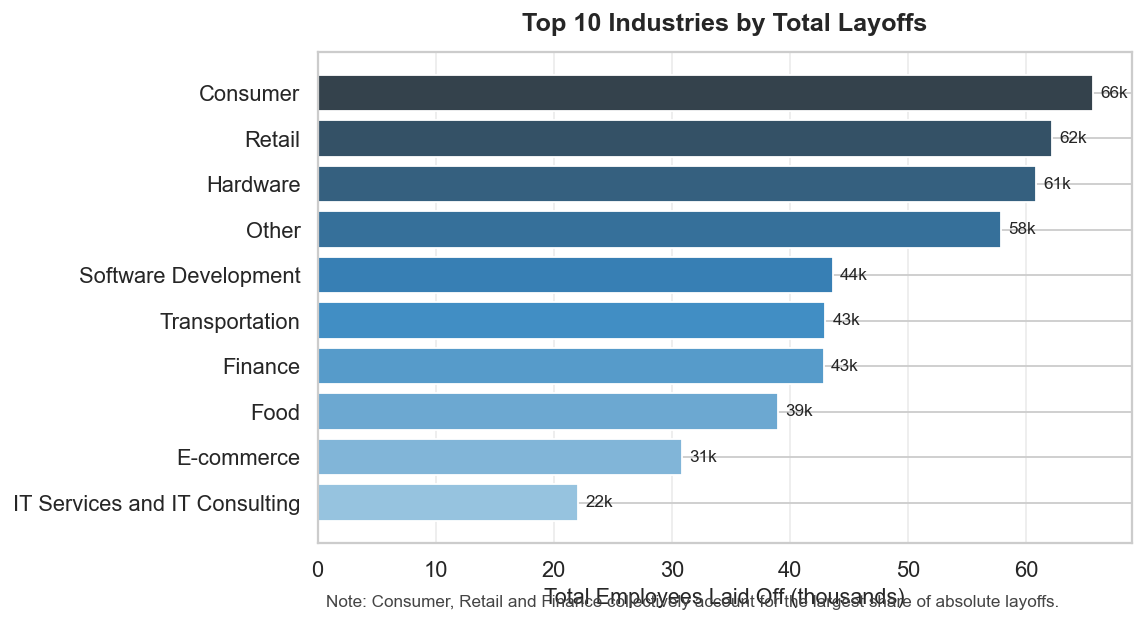

In [5]:
# ── Top 10 industries by total absolute layoffs ───────────────────────────────
top_ind = df_raw.groupby('Industry')['Laid_Off'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_ind.index[::-1], top_ind.values[::-1] / 1000,
               color=sns.color_palette("Blues_d", 10), edgecolor='white')
ax.bar_label(bars, labels=[f"{v/1000:.0f}k" for v in top_ind.values[::-1]], padding=4, fontsize=9.5)
ax.set_xlabel("Total Employees Laid Off (thousands)", fontsize=12)
ax.set_title("Top 10 Industries by Total Layoffs", fontsize=14, fontweight='bold', pad=12)
ax.grid(axis='x', alpha=0.35)
ax.text(0.01, -0.13,
        "Note: Consumer, Retail and Finance collectively account for the largest share of absolute layoffs.",
        transform=ax.transAxes, fontsize=9.5, color='#444')
plt.tight_layout()
plt.savefig('images/top_industries.png', bbox_inches='tight', dpi=150)
plt.show()


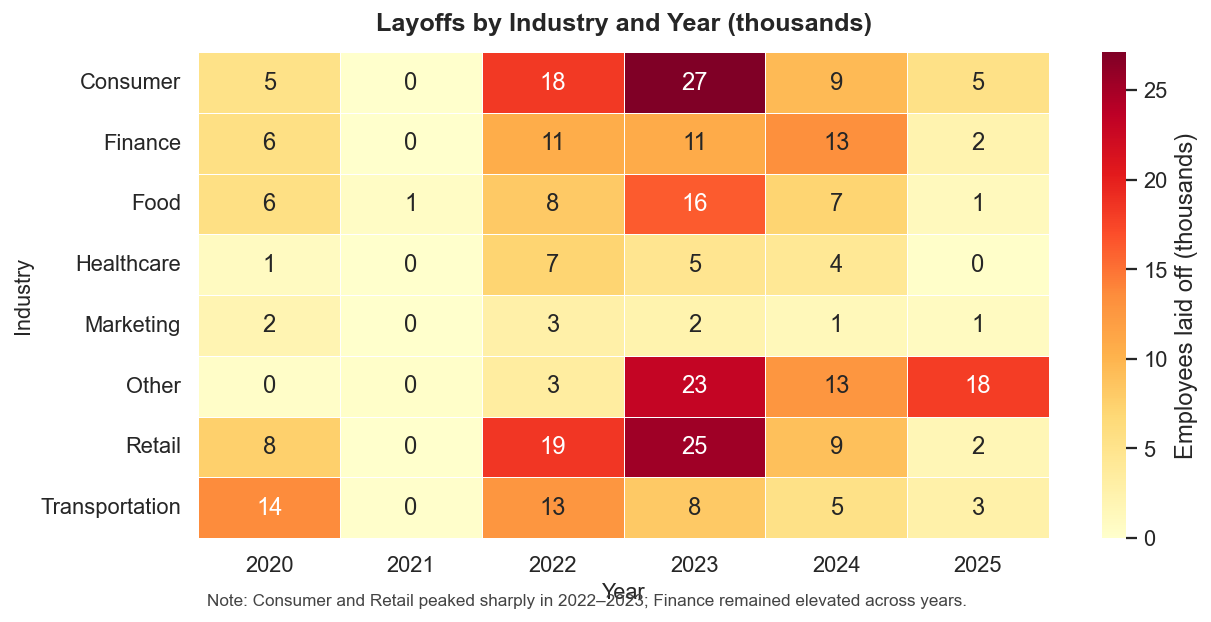

In [6]:
# ── Heatmap: layoffs by industry and year ────────────────────────────────────
# This cross-tabulation reveals which sectors were most exposed in each year,
# complementing the aggregate bar chart with a temporal breakdown.
top_inds = df_raw['Industry'].value_counts().head(8).index
pivot = (df_raw[df_raw['Industry'].isin(top_inds)]
         .pivot_table(values='Laid_Off', index='Industry',
                      columns='Year', aggfunc='sum', fill_value=0)) / 1000

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'label': 'Employees laid off (thousands)'})
ax.set_title("Layoffs by Industry and Year (thousands)", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Industry", fontsize=12)
ax.text(0.01, -0.14,
        "Note: Consumer and Retail peaked sharply in 2022–2023; Finance remained elevated across years.",
        transform=ax.transAxes, fontsize=9.5, color='#444')
plt.tight_layout()
plt.savefig('images/heatmap_industry_year.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.5 Funding Stage and % Laid Off

Before running formal tests, it is useful to visually inspect how layoff severity varies across funding stages.

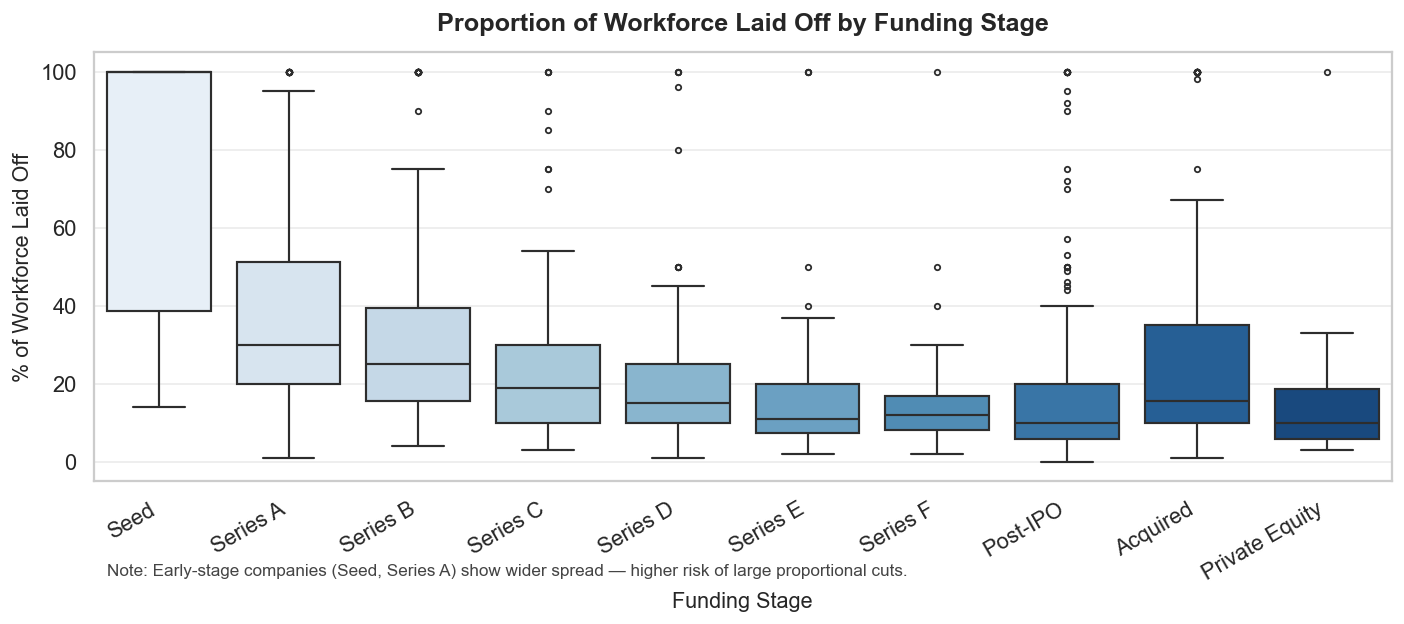

In [7]:
# ── Distribution of % laid off by funding stage (EDA) ────────────────────────
stage_order = ['Seed', 'Series A', 'Series B', 'Series C', 'Series D',
               'Series E', 'Series F', 'Post-IPO', 'Acquired', 'Private Equity']
df_stage = df_raw[df_raw['Stage'].isin(stage_order) & df_raw['Percentage'].notna()].copy()

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_stage, x='Stage', y='Percentage', order=stage_order,
            palette='Blues', fliersize=3, linewidth=1.2, ax=ax)
ax.set_xlabel("Funding Stage", fontsize=12)
ax.set_ylabel("% of Workforce Laid Off", fontsize=12)
ax.set_title("Proportion of Workforce Laid Off by Funding Stage",
             fontsize=14, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.grid(axis='y', alpha=0.35)
ax.text(0.01, -0.22,
        "Note: Early-stage companies (Seed, Series A) show wider spread — higher risk of large proportional cuts.",
        transform=ax.transAxes, fontsize=9.5, color='#444')
plt.tight_layout()
plt.savefig('images/pct_by_stage.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 4. Method 1 - Spearman Correlation + OLS Regression

### 4.1 Rationale

**Hypothesis H1:** Companies that raised more capital cut a smaller proportion of their workforce.

Two complementary methods are used:

- **Spearman's Rank Correlation** - tests for a monotonic association without assuming linearity or normality, which is appropriate given the heavy-tailed distributions of both `Money_Raised` and `Percentage`.
- **OLS Log-Linear Regression** - estimates the magnitude of the effect after log-transforming the right-skewed capital variable, providing an interpretable coefficient and R2.

A log1p transformation is applied to `Money_Raised_in__mil` to reduce skewness before fitting the regression. The outcome variable `Percentage` is kept on its original scale.


In [8]:
# ── Data preparation ──────────────────────────────────────────────────────────
# We restrict to rows with valid values for both variables.
# No imputation is performed — analysing complete cases avoids introducing
# artificial variance that could bias the correlation estimates.
df_m1 = df_raw[df_raw['Money_Raised_in__mil'].notna() &
               df_raw['Percentage'].notna() &
               (df_raw['Money_Raised_in__mil'] > 0)].copy()

df_m1['log_money'] = np.log1p(df_m1['Money_Raised_in__mil'])

print(f"Analysis sample: n = {len(df_m1):,} events")
print(f"\nMoney Raised ($M) — skewness before log: {df_m1['Money_Raised_in__mil'].skew():.2f}")
print(f"Money Raised ($M) — skewness after log:  {df_m1['log_money'].skew():.2f}")
display(df_m1[['Money_Raised_in__mil', 'log_money', 'Percentage']].describe().T.round(2))


Analysis sample: n = 1,789 events

Money Raised ($M) — skewness before log: 22.30
Money Raised ($M) — skewness after log:  -0.24


,count,mean,std,min,25%,50%,75%,max
Money_Raised_in__mil,1789.0,699.87,4527.26,1.00,52.00,166.00,455.00,121900.00
log_money,1789.0,4.96,1.71,0.69,3.97,5.12,6.12,11.71
Percentage,1789.0,24.96,25.70,0.00,10.00,16.00,30.00,100.00


In [9]:
# ── Spearman correlation ──────────────────────────────────────────────────────
rho, p_val = spearmanr(df_m1['log_money'], df_m1['Percentage'])

print("── Spearman's Rank Correlation ──")
print(f"  ρ       = {rho:.3f}")
print(f"  p-value = {p_val:.2e}")
print(f"  n       = {len(df_m1):,}")
if p_val < 0.05:
    print("  → Reject H₀: significant negative monotonic association detected.")
else:
    print("  → Fail to reject H₀.")


── Spearman's Rank Correlation ──
  ρ       = -0.316
  p-value = 6.92e-43
  n       = 1,789
  → Reject H₀: significant negative monotonic association detected.


Bootstrap 95% CI for ρ: [-0.361, -0.274]


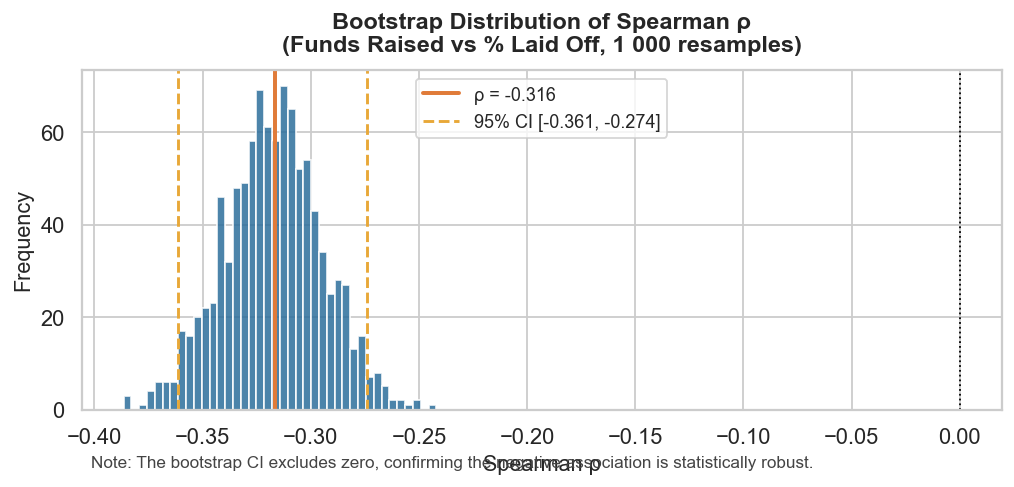

In [10]:
# ── Bootstrap 95% CI for Spearman ρ ──────────────────────────────────────────
# The asymptotic p-value assumes large-sample normality of the test statistic.
# A bootstrap CI provides a distribution-free alternative that is more reliable
# with skewed data, and makes the uncertainty around ρ explicit.
rng     = np.random.default_rng(42)
lm_arr  = df_m1['log_money'].values
pct_arr = df_m1['Percentage'].values

boot_rhos = []
for _ in range(1000):
    idx = rng.choice(len(lm_arr), len(lm_arr), replace=True)
    boot_rhos.append(spearmanr(lm_arr[idx], pct_arr[idx])[0])

ci_low, ci_high = np.percentile(boot_rhos, [2.5, 97.5])
print(f"Bootstrap 95% CI for ρ: [{ci_low:.3f}, {ci_high:.3f}]")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_rhos, bins=40, color="#2C6E9B", edgecolor='white', alpha=0.85)
ax.axvline(rho,     color="#E07B39", lw=2.2, label=f"ρ = {rho:.3f}")
ax.axvline(ci_low,  color='#E8A838', lw=1.6, ls='--',
           label=f"95% CI [{ci_low:.3f}, {ci_high:.3f}]")
ax.axvline(ci_high, color='#E8A838', lw=1.6, ls='--')
ax.axvline(0,       color='black',   lw=1,   ls=':')
ax.set_xlabel("Spearman ρ", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Bootstrap Distribution of Spearman ρ\n(Funds Raised vs % Laid Off, 1 000 resamples)",
             fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10)
ax.text(0.01, -0.17,
        "Note: The bootstrap CI excludes zero, confirming the negative association is statistically robust.",
        transform=ax.transAxes, fontsize=9.5, color='#444')
plt.tight_layout()
plt.savefig('images/spearman_bootstrap.png', bbox_inches='tight', dpi=150)
plt.show()


In [11]:
# ── OLS regression: log(Money Raised) → % Laid Off ───────────────────────────
X     = sm.add_constant(df_m1['log_money'].values)
y     = df_m1['Percentage'].values
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     206.9
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           1.80e-44
Time:                        17:50:23   Log-Likelihood:                -8248.0
No. Observations:                1789   AIC:                         1.650e+04
Df Residuals:                    1787   BIC:                         1.651e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.0221      1.769     27.710      0.0

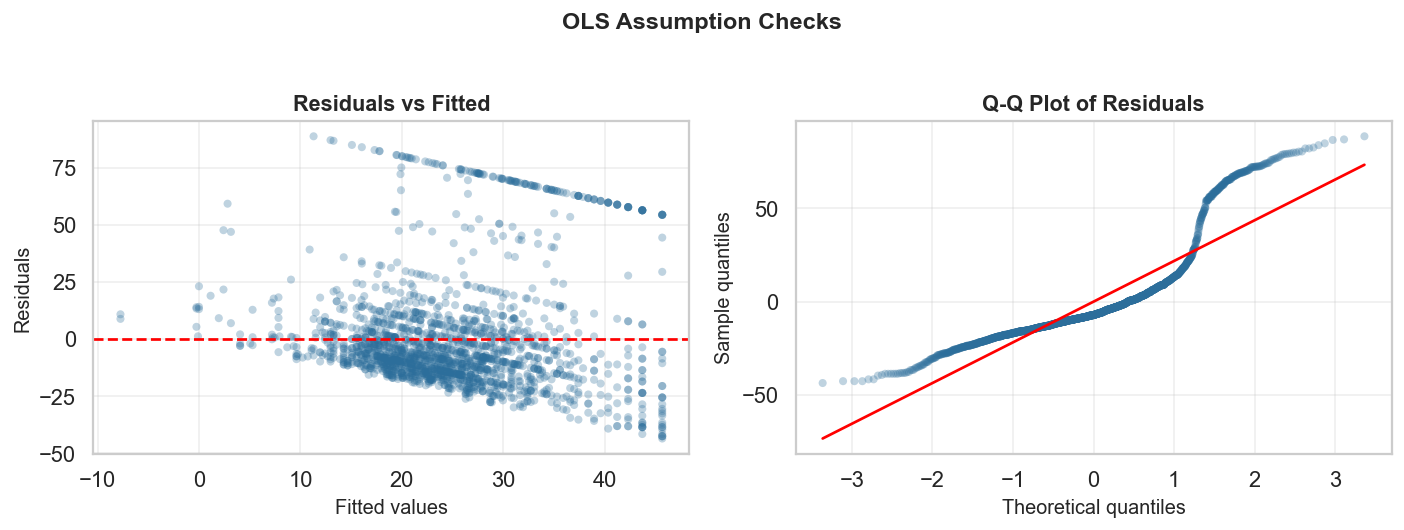

Note: Residuals show some right skew — expected with a bounded outcome.
Spearman provides a robust complement that does not rely on normality.


In [12]:
# ── Assumption checks: residuals vs fitted & Q-Q plot ─────────────────────────
# These two plots help assess whether the OLS assumptions hold:
#   • Residuals vs Fitted — checks for non-linearity and heteroskedasticity
#   • Q-Q plot          — checks whether residuals are approximately normal
# Some deviation from normality is expected given the bounded [0,100] outcome;
# this is why Spearman (assumption-free) is used as the primary test.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(model.fittedvalues, model.resid,
                alpha=0.3, s=20, color="#2C6E9B", edgecolors='none')
axes[0].axhline(0, color='red', lw=1.5, ls='--')
axes[0].set_xlabel("Fitted values", fontsize=11)
axes[0].set_ylabel("Residuals", fontsize=11)
axes[0].set_title("Residuals vs Fitted", fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

(osm, osr), (slope, intercept, r) = scipy_stats.probplot(model.resid, dist="norm")
axes[1].scatter(osm, osr, alpha=0.3, s=20, color="#2C6E9B", edgecolors='none')
axes[1].plot(osm, slope * np.array(osm) + intercept, color='red', lw=1.5)
axes[1].set_xlabel("Theoretical quantiles", fontsize=11)
axes[1].set_ylabel("Sample quantiles", fontsize=11)
axes[1].set_title("Q-Q Plot of Residuals", fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle("OLS Assumption Checks", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/ols_assumptions.png', bbox_inches='tight', dpi=150)
plt.show()
print("Note: Residuals show some right skew — expected with a bounded outcome.")
print("Spearman provides a robust complement that does not rely on normality.")


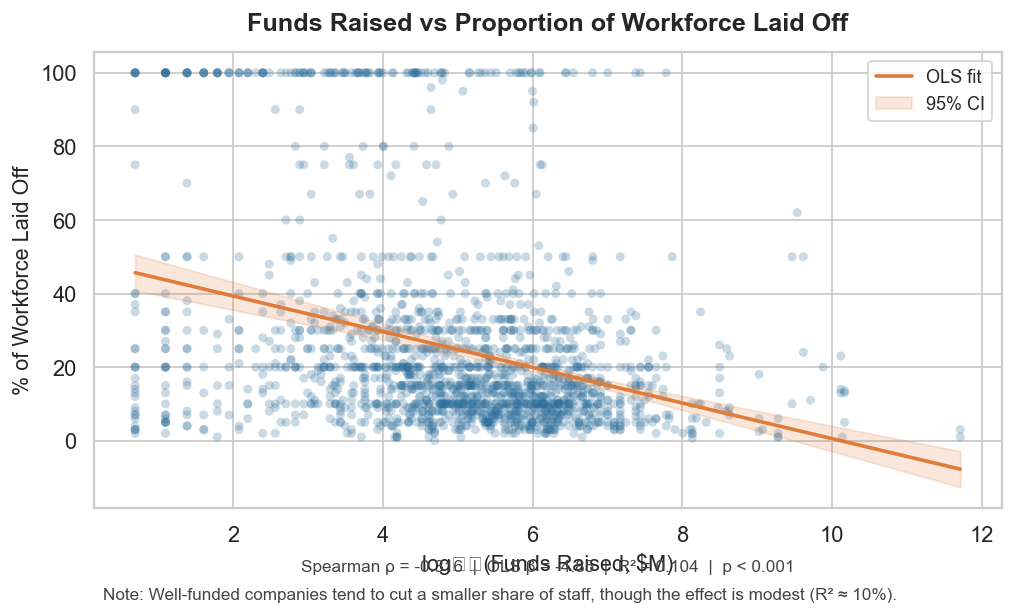

In [13]:
# ── Scatter plot with OLS fit and 95% confidence band ────────────────────────
beta   = model.params[1]
p_beta = model.pvalues[1]
r2     = model.rsquared

x_line    = np.linspace(df_m1['log_money'].min(), df_m1['log_money'].max(), 300)
pred_mean = model.params[0] + beta * x_line
n         = len(df_m1)
se_line   = np.sqrt(model.mse_resid * (1/n + (x_line - x_line.mean())**2 /
                    np.sum((x_line - x_line.mean())**2)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_m1['log_money'], df_m1['Percentage'],
           alpha=0.25, color="#2C6E9B", s=25, edgecolors='none')
ax.plot(x_line, pred_mean, color="#E07B39", lw=2, label='OLS fit')
ax.fill_between(x_line, pred_mean - 1.96*se_line, pred_mean + 1.96*se_line,
                color="#E07B39", alpha=0.18, label='95% CI')
ax.set_xlabel("log₁₊(Funds Raised, $M)", fontsize=12)
ax.set_ylabel("% of Workforce Laid Off", fontsize=12)
ax.set_title("Funds Raised vs Proportion of Workforce Laid Off",
             fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.text(0.5, -0.14,
        f"Spearman ρ = {rho:.3f}  |  OLS β = {beta:.2f}  |  R² = {r2:.3f}  |  p < 0.001",
        transform=ax.transAxes, fontsize=9.5, ha='center', color='#444')
ax.text(0.01, -0.20,
        "Note: Well-funded companies tend to cut a smaller share of staff, though the effect is modest (R² ≈ 10%).",
        transform=ax.transAxes, fontsize=9.5, color='#444')
plt.tight_layout()
plt.savefig('images/money_vs_pct.png', bbox_inches='tight', dpi=150)
plt.show()


In [14]:
# ── Method 1 results summary ──────────────────────────────────────────────────
results_m1 = pd.DataFrame({
    'Metric':         ['Spearman ρ', 'p-value', 'Bootstrap 95% CI', 'OLS β', 'OLS R²', 'Conclusion'],
    'Value':          [f'{rho:.3f}', f'{p_val:.2e}', f'[{ci_low:.3f}, {ci_high:.3f}]',
                       f'{beta:.3f}', f'{r2:.3f}', 'Reject H₀'],
    'Interpretation': [
        'Negative monotonic association',
        'Statistically significant',
        'CI excludes zero — robust result',
        'Each log-unit increase in capital → −4.8 pp cut',
        '~10% of variance in % laid off explained',
        'More capital is associated with smaller proportional cuts'
    ]
})
display(results_m1.style.set_table_styles(
    [{'selector': 'td, th', 'props': [('font-size', '11pt'), ('padding', '6px')]}]
))


,Metric,Value,Interpretation
0,Spearman ρ,-0.316,Negative monotonic association
1,p-value,6.92e-43,Statistically significant
2,Bootstrap 95% CI,"[-0.361, -0.274]",CI excludes zero — robust result
3,OLS β,-4.848,Each log-unit increase in capital → −4.8 pp cut
4,OLS R²,0.104,~10% of variance in % laid off explained
5,Conclusion,Reject H₀,More capital is associated with smaller proportional cuts


### 4.2 Method 1 Interpretation

The Spearman rank correlation between log-transformed funds raised and the percentage of the workforce laid off is **rho = -0.316 (p < 0.001)**, with a bootstrap 95% CI of **[-0.361, -0.274]** that excludes zero. This confirms a statistically robust negative monotonic association: companies that raised more capital tend to cut a smaller proportion of their workforce.

The OLS regression reinforces this finding: each one-unit increase in log(funds raised) is associated with approximately **4.8 percentage points fewer employees cut** (beta = -4.85, p < 0.001, R2 = 0.104).

However, with R2 around 10%, capital raised explains only a modest share of the variance in layoff severity. Other factors such as macroeconomic conditions, leadership decisions, and sector dynamics clearly play a larger role. H1 is supported, but the practical effect size is limited.


---
## 5. Method 2 - Kruskal-Wallis Test

### 5.1 Rationale

**Hypothesis H2:** Layoff severity (% of workforce) differs significantly across funding stage groups.

The **Kruskal-Wallis test** is used here as a non-parametric alternative to one-way ANOVA because:
- The `Percentage` variable is bounded between 0 and 100, non-normal, and right-skewed
- Group sample sizes vary significantly across stages
- The goal is to test whether the full distributions differ, not just the means

Funding stages are grouped into five categories to reflect real business maturity thresholds and to ensure adequate sample sizes per group.


In [15]:
# ── Create funding stage groups ───────────────────────────────────────────────
# Grouping rationale:
#   Early-Stage  (Seed, A)    — pre-product-market-fit, high burn, limited runway
#   Growth-Stage (B, C, D)    — scaling, but not yet generating stable cash flows
#   Late-Stage   (E+)         — approaching IPO readiness, larger cash reserves
#   Post-IPO                  — public markets access, most capital-resilient
#   Acquired / Private Equity — different ownership dynamic, often cost-cutting mandates
stage_groups = {
    'Early-Stage\n(Seed–A)':   ['Seed', 'Series A'],
    'Growth-Stage\n(B–D)':     ['Series B', 'Series C', 'Series D'],
    'Late-Stage\n(E+)':        ['Series E', 'Series F', 'Series H', 'Series G', 'Series I', 'Series J'],
    'Post-IPO':                  ['Post-IPO'],
    'Acquired /\nPrivate Eq.': ['Acquired', 'Private Equity']
}
df_raw['StageGroup'] = df_raw['Stage'].map(
    {stage: group for group, stages in stage_groups.items() for stage in stages})

df_kw = df_raw[df_raw['StageGroup'].notna() & df_raw['Percentage'].notna()].copy()

print("── Sample sizes and descriptive stats per group ──")
summary_kw = (df_kw.groupby('StageGroup')['Percentage']
              .agg(['count', 'median', 'mean', 'std'])
              .rename(columns={'count': 'n', 'median': 'Median %', 'mean': 'Mean %', 'std': 'SD'})
              .reindex(stage_groups.keys())
              .round(2))
display(summary_kw)


── Sample sizes and descriptive stats per group ──


,n,Median %,Mean %,SD
StageGroup,,,,
Early-Stage\n(Seed–A),158,34.5,50.23,34.30
Growth-Stage\n(B–D),624,20.0,26.09,22.69
Late-Stage\n(E+),222,11.0,15.35,14.98
Post-IPO,460,10.0,16.29,18.68
Acquired /\nPrivate Eq.,156,15.0,28.60,32.28


In [16]:
# ── Kruskal–Wallis test ───────────────────────────────────────────────────────
groups_data = [df_kw[df_kw['StageGroup'] == g]['Percentage'].values
               for g in stage_groups.keys()]
stat_kw, p_kw = kruskal(*groups_data)

print("── Kruskal–Wallis Test ──")
print(f"  H-statistic = {stat_kw:.2f}")
print(f"  p-value     = {p_kw:.2e}")
print(f"  df          = {len(stage_groups) - 1}")
if p_kw < 0.05:
    print("  → Reject H₀: significant difference in layoff severity across funding stages.")
else:
    print("  → Fail to reject H₀.")


── Kruskal–Wallis Test ──
  H-statistic = 277.92
  p-value     = 6.25e-59
  df          = 4
  → Reject H₀: significant difference in layoff severity across funding stages.


In [17]:
# ── Post-hoc: pairwise Mann–Whitney U (Bonferroni correction) ─────────────────
# Kruskal-Wallis only tells us *that* groups differ, not *which* pairs.
# Mann-Whitney U tests are run for all 10 pairwise comparisons.
# Bonferroni correction adjusts the significance threshold to control the
# family-wise error rate: α_corrected = 0.05 / 10 = 0.005.
from itertools import combinations

stage_keys    = list(stage_groups.keys())
labels_clean  = ['Early', 'Growth', 'Late', 'Post-IPO', 'Acq/PE']
n_comparisons = len(list(combinations(range(len(stage_keys)), 2)))
alpha_bonf    = 0.05 / n_comparisons

print(f"Bonferroni-corrected α = {alpha_bonf:.4f}\n")
print(f"{'Comparison':<35} {'U-stat':>10} {'p-value':>12} {'Significant?':>14}")
print("-" * 75)
for (i, g1), (j, g2) in combinations(enumerate(stage_keys), 2):
    u_stat, p_mw = mannwhitneyu(
        df_kw[df_kw['StageGroup'] == g1]['Percentage'],
        df_kw[df_kw['StageGroup'] == g2]['Percentage'],
        alternative='two-sided')
    sig   = "✓" if p_mw < alpha_bonf else "✗"
    label = f"{labels_clean[i]} vs {labels_clean[j]}"
    print(f"{label:<35} {u_stat:>10.0f} {p_mw:>12.4f} {sig:>14}")


Bonferroni-corrected α = 0.0050

Comparison                              U-stat      p-value   Significant?
---------------------------------------------------------------------------
Early vs Growth                          71644       0.0000              ✓
Early vs Late                            30143       0.0000              ✓
Early vs Post-IPO                        62012       0.0000              ✓
Early vs Acq/PE                          18164       0.0000              ✓
Growth vs Late                           95543       0.0000              ✓
Growth vs Post-IPO                      199722       0.0000              ✓
Growth vs Acq/PE                         55296       0.0084              ✗
Late vs Post-IPO                         53048       0.4091              ✗
Late vs Acq/PE                           13986       0.0014              ✓
Post-IPO vs Acq/PE                       28050       0.0000              ✓


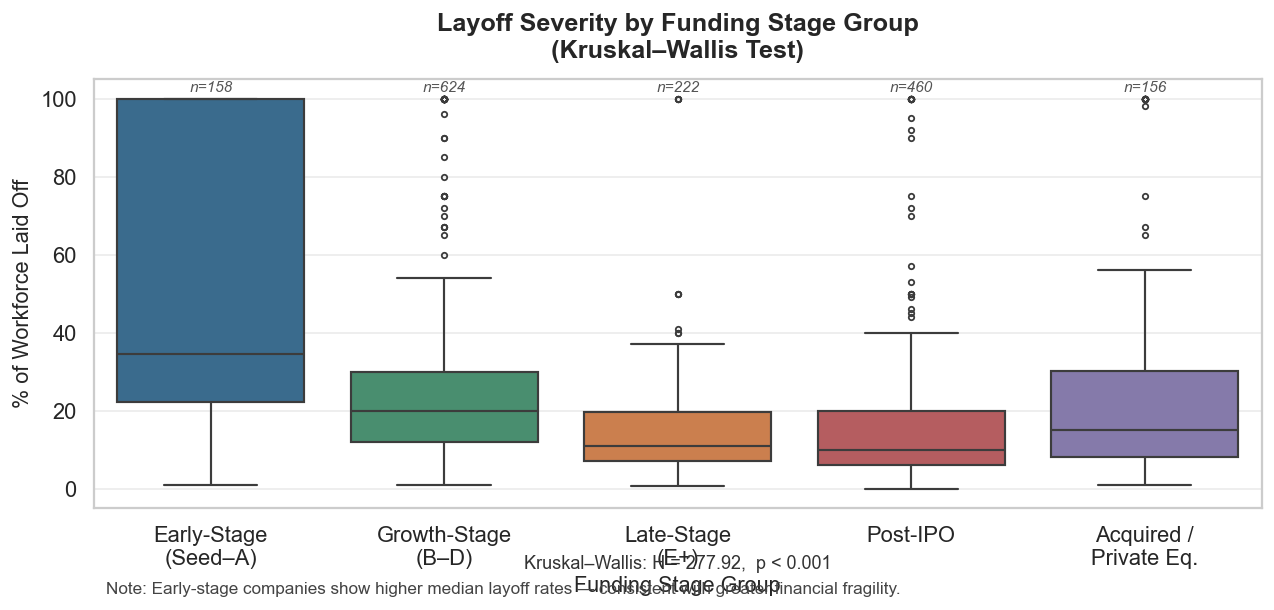

In [18]:
# ── Boxplot: layoff severity by funding stage group ───────────────────────────
counts_kw = df_kw.groupby('StageGroup')['Percentage'].count().reindex(stage_groups.keys())

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_kw, x='StageGroup', y='Percentage',
            order=list(stage_groups.keys()),
            palette=['#2C6E9B', '#3D9970', '#E07B39', '#C44E52', '#8172B2'],
            fliersize=3, linewidth=1.2, ax=ax)
for i, g in enumerate(stage_groups.keys()):
    ax.text(i, ax.get_ylim()[1] * 0.97, f"n={counts_kw[g]}",
            ha='center', fontsize=8.5, color='#555', style='italic')
ax.set_xlabel("Funding Stage Group", fontsize=12)
ax.set_ylabel("% of Workforce Laid Off", fontsize=12)
ax.set_title("Layoff Severity by Funding Stage Group\n(Kruskal–Wallis Test)",
             fontsize=14, fontweight='bold', pad=12)
ax.grid(axis='y', alpha=0.35)
ax.text(0.5, -0.14, f"Kruskal–Wallis: H = {stat_kw:.2f},  p < 0.001",
        transform=ax.transAxes, ha='center', fontsize=10, color='#333')
ax.text(0.01, -0.20,
        "Note: Early-stage companies show higher median layoff rates — consistent with greater financial fragility.",
        transform=ax.transAxes, fontsize=9.5, color='#444')
plt.tight_layout()
plt.savefig('images/kruskal_stage.png', bbox_inches='tight', dpi=150)
plt.show()


In [19]:
# ── Method 2 results summary ──────────────────────────────────────────────────
results_m2 = pd.DataFrame({
    'Metric':         ['H-statistic', 'p-value', 'df', 'Conclusion'],
    'Value':          [f'{stat_kw:.2f}', f'{p_kw:.2e}', f'{len(stage_groups)-1}', 'Reject H₀'],
    'Interpretation': [
        'Large test statistic — strong group differences',
        'Extremely significant (p < 0.001)',
        '4 degrees of freedom',
        'Layoff severity differs significantly across funding stages'
    ]
})
display(results_m2.style.set_table_styles(
    [{'selector': 'td, th', 'props': [('font-size', '11pt'), ('padding', '6px')]}]
))


,Metric,Value,Interpretation
0,H-statistic,277.92,Large test statistic — strong group differences
1,p-value,6.25e-59,Extremely significant (p < 0.001)
2,df,4,4 degrees of freedom
3,Conclusion,Reject H₀,Layoff severity differs significantly across funding stages


### 5.2 Method 2 Interpretation

The Kruskal-Wallis test yields **H = 277.92 (p < 0.001)**, strongly rejecting the null hypothesis that layoff severity is identically distributed across funding stage groups.

Pairwise Mann-Whitney U tests (Bonferroni-corrected) confirm that early-stage companies (Seed-Series A) cut significantly larger proportions of their workforce than both Post-IPO and Growth-stage companies. This is consistent with the idea that financial maturity acts as a buffer: post-IPO companies have access to public capital markets and larger cash reserves.

H2 is supported. The funding stage at the time of layoff is a significant predictor of layoff severity.


---
## 6. Reflection on the Use of AI

### Tools used
Claude (Anthropic) was used throughout this project as a coding assistant.

### How AI was used

**Data exploration and cleaning:** Claude was used to discuss how to handle missing values in `Percentage`, `Stage`, and `Money_Raised_in__mil`. The decision to analyse each variable on its available complete cases rather than imputing was made after considering the trade-offs involved.

**Visualisation:** Claude suggested the boxplot with sample size annotations for the Kruskal-Wallis chart, and the `fill_between` technique for confidence bands. The colour palette and layout were adjusted manually.

**Reproducibility design:** Claude suggested using `os.makedirs("images", exist_ok=True)` combined with `plt.savefig(...)` inside each plot cell, so that running the notebook from scratch automatically regenerates all figures. This was a deliberate choice to make the analysis fully reproducible rather than relying on pre-generated images.

**Statistical choices:** The grouping of funding stages (Seed+A, B-D, E+, Post-IPO, Acquired/PE) reflects my own reasoning about what constitutes meaningful business maturity thresholds. Claude helped draft the initial grouping and pointed out the risk of small sample sizes in later series (H, I, J).

**Example prompt:**
> "The scatter plot of Money Raised vs % laid off looks compressed because of outliers. What transformation would you recommend, and how should I handle the OLS model afterwards?"

This led to the log1p transformation and the decision to pair Spearman with OLS rather than relying on either alone.

### What I contributed beyond AI

- Framing the research question around financial maturity as a buffer, rather than simply describing the data
- Choosing Kruskal-Wallis over ANOVA based on the bounded nature of the outcome variable
- Validating Spearman with a bootstrap CI rather than relying on the asymptotic p-value alone
- Interpreting R2 around 10% critically and concluding that capital is a signal, not the dominant driver
- Structuring the analysis from EDA to Method 1 to Method 2 to build a coherent argument


---
## 7. Conclusion

### Summary of findings

This analysis of 2,412 tech layoff events from 2020 to 2025 shows that financial maturity and capital availability are meaningful but incomplete predictors of layoff severity.

Companies that raised more capital cut proportionally fewer employees (Spearman rho = -0.316, OLS R2 approx. 10%), and early-stage companies faced significantly larger proportional cuts than Post-IPO peers (Kruskal-Wallis H = 277.92, p < 0.001). These findings support the idea that financial reserves act as a buffer in downturns, but the limited explained variance suggests that other forces dominate: macroeconomic conditions, sector dynamics, leadership decisions, and investor pressure.

The 2022-2023 peak, driven by post-pandemic overhiring corrections and rising interest rates, affected virtually all stages and sectors, illustrating that systemic shocks can override firm-level financial characteristics.

### Limitations

1. **Selection bias:** The dataset covers only publicly reported layoffs. Small events at private companies are likely underrepresented, which may overstate layoff rates for early-stage firms.
2. **Proxy quality:** `Money_Raised_in__mil` is a crude proxy for financial health. Companies may have burned through capital before the layoff event; a runway measure would be more precise.
3. **Causality:** Both analyses are observational. Reverse causality is plausible: healthier companies both raise more and lay off less.
4. **Stage timing:** The recorded funding stage may not reflect the company's actual financial position at the time of the layoff.

### Possible improvements

- Adding macroeconomic controls such as the Federal funds rate or quarterly VC investment volume
- Replacing `Money_Raised` with a runway proxy (funds raised divided by company size)
- Using panel regression with company fixed effects to account for unobserved firm-level differences
- Modelling a binary outcome (layoff above 20% of workforce) using logistic regression


---
## 8. References

- Herold, U. (2026). *Tech Layoffs 2020–2025*. Kaggle Dataset. https://www.kaggle.com/datasets/ulrikeherold/tech-layoffs-2020-2024
- Kruskal, W. H., & Wallis, W. A. (1952). Use of ranks in one-criterion variance analysis. *Journal of the American Statistical Association*, 47(260), 583–621.
- Spearman, C. (1904). The proof and measurement of association between two things. *The American Journal of Psychology*, 15(1), 72–101.
- Layoffs.fyi (2024). *Tech Layoff Tracker*. https://layoffs.fyi
